# Download Sentinel-3 data from copernicus.eu

https://documentation.dataspace.copernicus.eu/APIs/openEO/Python_Client/Python.html

https://github.com/eu-cdse/notebook-samples/tree/main/openeo

In [1]:
!pip install openeo

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cmocean as cm
import numpy as np

In [3]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu")

See: https://documentation.dataspace.copernicus.eu/APIs/openEO/Collections.html

In [4]:
connection.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [5]:
# List collections available on the openEO back-end
connection.list_collection_ids()

# Get detailed metadata of a certain collection
connection.describe_collection("SENTINEL2_L2A")
#connection.describe_collection("SENTINEL3_SLSTR")

#connection.describe_collection("SENTINEL3_SYN_L2_SYN")
#connection.describe_collection("SENTINEL3_OLCI_L1B")

{'assets': {'thumbnail': {'href': 'https://www.esa.int/var/esa/storage/images/esa_multimedia/images/2022/07/tallinn_estonia/24383281-1-eng-GB/Tallinn_Estonia_pillars.jpg',
   'roles': ['thumbnail'],
   'title': 'Sentinel 2 L2A',
   'type': 'image/png'}},
 'cube:dimensions': {'bands': {'type': 'bands',
   'values': ['B01',
    'B02',
    'B03',
    'B04',
    'B05',
    'B06',
    'B07',
    'B08',
    'B8A',
    'B09',
    'B11',
    'B12',
    'WVP',
    'AOT',
    'SCL',
    'sunAzimuthAngles',
    'sunZenithAngles',
    'viewAzimuthMean',
    'viewZenithMean']},
  't': {'extent': ['2015-07-04T00:00:00Z', None], 'type': 'temporal'},
  'x': {'axis': 'x',
   'extent': [-180, 180],
   'reference_system': {'$schema': 'https://proj.org/schemas/v0.2/projjson.schema.json',
    'area': 'World',
    'bbox': {'east_longitude': 180,
     'north_latitude': 90,
     'south_latitude': -90,
     'west_longitude': -180},
    'coordinate_system': {'axis': [{'abbreviation': 'Lat',
       'direction': 'north',
       'name': 'Geodetic latitude',
       'unit': 'degree'},
      {'abbreviation': 'Lon',
       'direction': 'east',
       'name': 'Geodetic longitude',
       'unit': 'degree'}],
     'subtype': 'ellipsoidal'},
    'datum': {'ellipsoid': {'inverse_flattening': 298.257223563,
      'name': 'WGS 84',
      'semi_major_axis': 6378137},
     'name': 'World Geodetic System 1984',
     'type': 'GeodeticReferenceFrame'},
    'id': {'authority': 'OGC', 'code': 'Auto42001', 'version': '1.3'},
    'name': 'AUTO 42001 (Universal Transverse Mercator)',
    'type': 'GeodeticCRS'},
   'step': 10,
   'type': 'spatial'},
  'y': {'axis': 'y',
   'extent': [-56, 83],
   'reference_system': {'$schema': 'https://proj.org/schemas/v0.2/projjson.schema.json',
    'area': 'World',
    'bbox': {'east_longitude': 180,
     'north_latitude': 90,
     'south_latitude': -90,
     'west_longitude': -180},
    'coordinate_system': {'axis': [{'abbreviation': 'Lat',
       'direction': 'north',
       'name': 'Geodetic latitude',
       'unit': 'degree'},
      {'abbreviation': 'Lon',
       'direction': 'east',
       'name': 'Geodetic longitude',
       'unit': 'degree'}],
     'subtype': 'ellipsoidal'},
    'datum': {'ellipsoid': {'inverse_flattening': 298.257223563,
      'name': 'WGS 84',
      'semi_major_axis': 6378137},
     'name': 'World Geodetic System 1984',
     'type': 'GeodeticReferenceFrame'},
    'id': {'authority': 'OGC', 'code': 'Auto42001', 'version': '1.3'},
    'name': 'AUTO 42001 (Universal Transverse Mercator)',
    'type': 'GeodeticCRS'},
   'step': 10,
   'type': 'spatial'}},
 'description': 'SENTINEL-2 is a wide-swath, high-resolution, multi-spectral imaging mission, supporting Copernicus Land Monitoring studies, including the monitoring of vegetation, soil and water cover, as well as observation of inland waterways and coastal areas. The SENTINEL-2 Multispectral Instrument (MSI) samples 13 spectral bands: four bands at 10 metres, six bands at 20 metres and three bands at 60 metres spatial resolution.\n The level 2A data is atmospherically corrected using Sen2Cor.',
 'extent': {'spatial': {'bbox': [[-180, -56, 180, 83]]},
  'temporal': {'interval': [['2015-07-04T00:00:00Z', None]]}},
 'id': 'SENTINEL2_L2A',
 'keywords': ['COPERNICUS',
  'ESA',
  'Orthoimagery',
  'Sentinel-2',
  'MSI',
  'Level-2A',
  'Radiometry',
  'Plant Resource',
  'TOC'],
 'license': 'proprietary',
 'links': [{'href': 'https://sentinels.copernicus.eu/documents/247904/690755/Sentinel_Data_Legal_Notice',
   'rel': 'license',
   'type': 'application/pdf'},
  {'href': 'https://documentation.dataspace.copernicus.eu/Data/SentinelMissions/Sentinel2.html#sentinel-2-level-2a-top-of-canopy-toc',
   'rel': 'alternate',
   'type': 'application/html'},
  {'href': 'https://dataspace.copernicus.eu/browser/?zoom=11&lat=45.36638&lng=12.49832&themeId=DEFAULT-THEME&visualizationUrl=https%3A%2F%2Fsh.dataspace.copernicus.eu%2Fogc%2Fwms%2F28b654e7-8912-4e59-9e58-85b58d768b3a&datasetId=S2

# Sentinel-2 scenes

21st Apr 2024:

https://apps.sentinel-hub.com/eo-browser/?zoom=9&lat=-22.08909&lng=113.27179&themeId=DEFAULT-THEME&visualizationUrl=https%3A%2F%2Fservices.sentinel-hub.com%2Fogc%2Fwms%2Fbd86bcc0-f318-402b-a145-015f85b9427e&datasetId=S2L2A&fromTime=2024-04-21T00%3A00%3A00.000Z&toTime=2024-04-21T23%3A59%3A59.999Z&layerId=1_TRUE_COLOR&gain=7&gamma=0.4&demSource3D=%22MAPZEN%22

27th Jan 2024:

https://apps.sentinel-hub.com/eo-browser/?zoom=9&lat=-22.21391&lng=113.02734&themeId=DEFAULT-THEME&visualizationUrl=https%3A%2F%2Fservices.sentinel-hub.com%2Fogc%2Fwms%2Fbd86bcc0-f318-402b-a145-015f85b9427e&datasetId=S2L2A&fromTime=2024-01-27T00%3A00%3A00.000Z&toTime=2024-01-27T23%3A59%3A59.999Z&layerId=2_FALSE_COLOR&gain=5.6&gamma=0.7&demSource3D=%22MAPZEN%22

14th October 2023:

https://apps.sentinel-hub.com/eo-browser/?zoom=9&lat=-22.44023&lng=113.29102&themeId=DEFAULT-THEME&visualizationUrl=https%3A%2F%2Fservices.sentinel-hub.com%2Fogc%2Fwms%2Fbd86bcc0-f318-402b-a145-015f85b9427e&datasetId=S2L2A&fromTime=2023-10-14T00%3A00%3A00.000Z&toTime=2023-10-14T23%3A59%3A59.999Z&layerId=6-SWIR&gain=2&gamma=0.5&demSource3D=%22MAPZEN%22


4 September 2023:

https://apps.sentinel-hub.com/eo-browser/?zoom=10&lat=-22.27576&lng=113.62335&themeId=DEFAULT-THEME&visualizationUrl=https%3A%2F%2Fservices.sentinel-hub.com%2Fogc%2Fwms%2Fbd86bcc0-f318-402b-a145-015f85b9427e&datasetId=S2L2A&fromTime=2023-09-04T00%3A00%3A00.000Z&toTime=2023-09-04T23%3A59%3A59.999Z&layerId=1_TRUE_COLOR&gain=0.5&gamma=0.5&demSource3D=%22MAPZEN%22

30 August 2023:

https://apps.sentinel-hub.com/eo-browser/?zoom=8&lat=-21.74164&lng=112.98889&themeId=DEFAULT-THEME&visualizationUrl=https%3A%2F%2Fservices.sentinel-hub.com%2Fogc%2Fwms%2Fbd86bcc0-f318-402b-a145-015f85b9427e&datasetId=S2L2A&fromTime=2023-08-30T00%3A00%3A00.000Z&toTime=2023-08-30T23%3A59%3A59.999Z&layerId=2_FALSE_COLOR&gain=2.6&gamma=0.4&demSource3D=%22MAPZEN%22

10 August 2023:

https://apps.sentinel-hub.com/eo-browser/?zoom=9&lat=-21.83251&lng=113.2251&themeId=DEFAULT-THEME&visualizationUrl=https%3A%2F%2Fservices.sentinel-hub.com%2Fogc%2Fwms%2Fbd86bcc0-f318-402b-a145-015f85b9427e&datasetId=S2L2A&fromTime=2023-08-10T00%3A00%3A00.000Z&toTime=2023-08-10T23%3A59%3A59.999Z&layerId=1_TRUE_COLOR&gain=2.6&gamma=0.4&demSource3D=%22MAPZEN%22



In [6]:
area = [112, -23, 114, -20] # Ningaloo
# t1,t2 = "2024-04-20", "2024-04-22"
# t1,t2 = "2024-01-26", "2024-01-29"
# t1,t2 = "2023-07-06", "2023-07-07"
t1,t2 = "2025-08-01", "2025-08-02"

datacube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent={"west": 112, "south": -23, "east": 114, "north": -20},
    temporal_extent = [t1,t2],
    bands=["B02"],
    #max_cloud_cover=100,
)

In [7]:
datacube

In [8]:
# === 全量依赖（同一格里一起导入，避免 NameError）===
import os, time, requests
import xarray as xr
import pandas as pd
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# === 用当前 datacube 生成 NetCDF，并新建 batch job ===
os.makedirs("../DATA", exist_ok=True)

cube = datacube.save_result(format="NetCDF")
job  = connection.create_job(cube, title=f"S2_B02_{t1}_{t2}")
job.start()

# === 轮询直到完成 ===
while True:
    st = job.status()
    print("status:", st)
    if st in ("finished", "error", "canceled"):
        break
    time.sleep(10)

if st != "finished":
    try:
        print("\n".join([e.get("message","") for e in job.logs()[-20:]]))
    except Exception:
        pass
    raise RuntimeError(f"Job ended with status: {st}")

# === 找到这个新 job 的 NetCDF 资产 ===
results  = job.get_results()
assets   = results.get_assets()
nc_asset = next(
    (a for a in assets
     if getattr(a, "href", "").lower().endswith(".nc")
     or "netcdf" in (getattr(a, "metadata", {}).get("type","").lower())),
    None
)
assert nc_asset, f"No NetCDF in assets: {assets}"
url = nc_asset.href
print("URL:", url)

# === 断点续传保存到以 t1 命名的文件 ===
outfile = f'../DATA/Sentinel2_L2A_B02_{t1}.nc'
for p in (outfile, outfile + ".part"):
    if os.path.exists(p):
        try: os.remove(p)
        except: pass

def segmented_resume_download(url, dest, segment_mb=4, timeout=90, max_seg_retries=6):
    tmp = dest + ".part"
    s = requests.Session()
    s.mount("https://", HTTPAdapter(max_retries=Retry(total=0)))
    s.mount("http://",  HTTPAdapter(max_retries=Retry(total=0)))
    try:
        total = int(s.head(url, allow_redirects=True, timeout=timeout).headers.get("Content-Length","0"))
    except Exception:
        total = 0
    done = os.path.getsize(tmp) if os.path.exists(tmp) else 0
    seg  = segment_mb * 1024 * 1024
    with open(tmp, "ab") as f:
        while True:
            if total and done >= total: break
            start = done
            end   = None if not total else min(done + seg - 1, total - 1)
            tries = 0
            while True:
                tries += 1
                headers = {"Range": f"bytes={start}-" + ("" if end is None else f"{end}"),
                           "Accept-Encoding": "identity"}
                try:
                    with s.get(url, headers=headers, stream=True, timeout=timeout) as r:
                        if r.status_code not in (200, 206):
                            raise IOError(f"HTTP {r.status_code}")
                        for chunk in r.iter_content(chunk_size=2*1024*1024):
                            if chunk:
                                f.write(chunk); done += len(chunk)
                    break
                except Exception:
                    if tries >= max_seg_retries: raise
                    time.sleep(2 * tries)
            if total:
                print(f"\r{done/1e6:8.1f}/{total/1e6:.1f} MB ({100*done/max(total,1):5.1f}%)", end="")
            else:
                print(f"\r{done/1e6:8.1f} MB", end="")
    os.replace(tmp, dest)
    print("\n[OK] Saved:", dest)

segmented_resume_download(url, outfile, segment_mb=4)

# === 快速校验（并确认时间）===
try:
    ds = xr.open_dataset(outfile)
except Exception:
    ds = xr.open_dataset(outfile, engine="h5netcdf")
print("time in file:", pd.to_datetime(ds["t"].values[0]))
print(ds.dims, list(ds.data_vars)[:5])
ds.close()


status: created
status: created
status: created
status: created
status: created
status: created
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: running
status: 

In [9]:
ds = xr.open_dataset(outfile)
ds

<xarray.Dataset> Size: 3GB
Dimensions:  (t: 1, x: 21145, y: 33488)
Coordinates:
  * t        (t) datetime64[ns] 8B 2025-08-01
  * x        (x) float64 169kB 6.025e+05 6.025e+05 ... 8.139e+05 8.139e+05
  * y        (y) float64 268kB 7.788e+06 7.788e+06 ... 7.453e+06 7.453e+06
Data variables:
    crs      |S1 1B ...
    B02      (t, y, x) float32 3GB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.67.0a7.dev20...
    description:  
    title:

In [10]:
pip install cmocean


Note: you may need to restart the kernel to use updated packages.


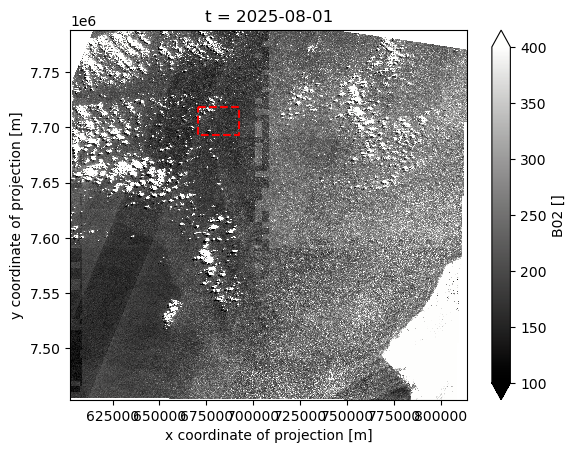

In [11]:
# t1 = "2023-07-06"
# t1 = "2024-04-16"
# vmin=50
# vmax=400

t1 = "2025-08-01"
vmin=100
vmax=400

# t1 = "2024-01-26"
# vmin=200
# vmax=900
# i1,i2 = 7800,8500
# j1,j2 = 8500,9200

# i1,i2 = 6000,8500 # Southern end
# j1,j2 = 8500,11000

i1,i2 = 6800,9000
j1,j2 = 7000,9500

# i1,i2 = 7500,9500
# j1,j2 = 5000,7500

# i1,i2 = 12200,13200
# j1,j2 = 2500,3500

outfile = f'../DATA/Sentinel2_L2A_B02_{t1}.nc'
ds = xr.open_dataset(outfile)

plt.figure()
ds['B02'].isel(t=0, x=slice(None,None, 5), y=slice(None,None,5)).plot.imshow(vmin=vmin, vmax=vmax, cmap="cmo.gray")

x = ds['x'].isel(x=[i1,i2])
y = ds['y'].isel(y=[j1,j2])
xbox = [x[0], x[1], x[1], x[0], x[0]]
ybox = [y[0], y[0], y[1], y[1], y[0]]

plt.plot(xbox, ybox, 'r--')

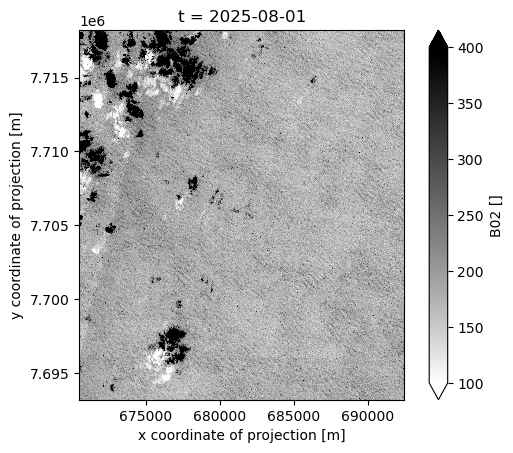

In [12]:
fig, ax = plt.subplots()
# ds['B02'].isel(t=0, x=slice(7500,8500, 1), y=slice(8000,9000,1)).plot.imshow(vmin=100, vmax=300, cmap="Blues")
ds['B02'].isel(t=0, x=slice(i1,i2, 1), y=slice(j1,j2,1)).plot.imshow(vmin=vmin, vmax=vmax, cmap="cmo.gray_r")

ax.set_aspect('equal')

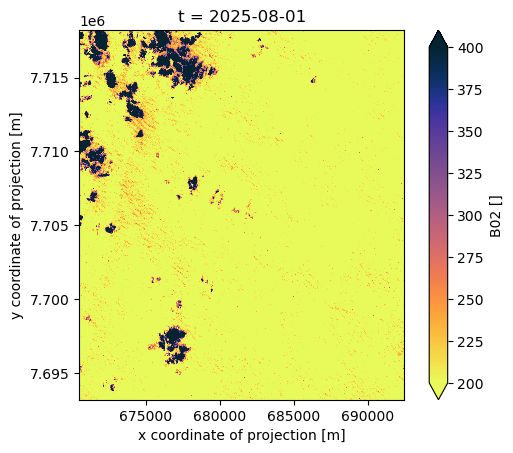

In [13]:
from scipy.signal import convolve2d
z2 = ds['B02'].isel(t=0, x=slice(i1,i2, 1), y=slice(j1,j2,1)).copy()
#z = ds_area['sigma0'].copy()

zc = z2.values#+1j
zc[np.isnan(zc)] = 0.
# zf,_,_,_ = filter2d(zc, 1, 1, 20, 0, 359.999, n=1)
# z[:] = np.abs(zf)

N=3
z2[:] = convolve2d(zc, np.ones((N,N))/N**2, mode='same')


fig, ax = plt.subplots()
# ds['B02'].isel(t=0, x=slice(7500,8500, 1), y=slice(8000,9000,1)).plot.imshow(vmin=100, vmax=300, cmap="Blues")
z2.plot.imshow(vmin=200, vmax=vmax, cmap="cmo.thermal_r")

ax.set_aspect('equal')

In [14]:

# z2 = ds['B02'].isel(t=0, x=slice(i1,i2, 1), y=slice(j1,j2,1)).copy()
# dx, dy = np.gradient(z)
# z2[:] = np.abs(dx+1j*dy)
# # z.plot.imshow(vmin=vmin, vmax=vmax, cmap="cmo.thermal")
# z2.plot.imshow(vmin=-10, vmax=10, cmap="cmo.gray_r", alpha=1)

# ax.set_aspect('equal')

<Figure size 640x480 with 0 Axes>

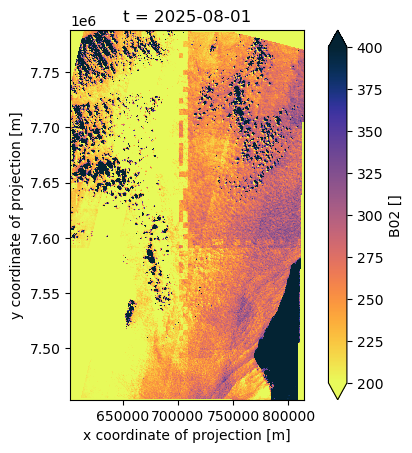

In [15]:
plt.figure()
z = ds['B02'].isel(t=0, x=slice(None,None, 5), y=slice(None,None,5)).copy()
#z = ds_area['sigma0'].copy()

zc = z.values#+1j
zc[np.isnan(zc)] = 0.
# zf,_,_,_ = filter2d(zc, 1, 1, 20, 0, 359.999, n=1)
# z[:] = np.abs(zf)

N=8
z[:] = convolve2d(zc, np.ones((N,N))/N**2, mode='same')

fig, ax = plt.subplots()
# ds['B02'].isel(t=0, x=slice(7500,8500, 1), y=slice(8000,9000,1)).plot.imshow(vmin=100, vmax=300, cmap="Blues")
z.plot.imshow(vmin=200, vmax=vmax, cmap="cmo.thermal_r")

ax.set_aspect('equal')

xbox = [x[0], x[1], x[1], x[0], x[0]]
ybox = [y[0], y[0], y[1], y[1], y[0]]

saved: ../FIGURES\NingalooSentinel2_2025-08-01_Blues_r.png


'../FIGURES\\NingalooSentinel2_2025-08-01_Blues_r.png'

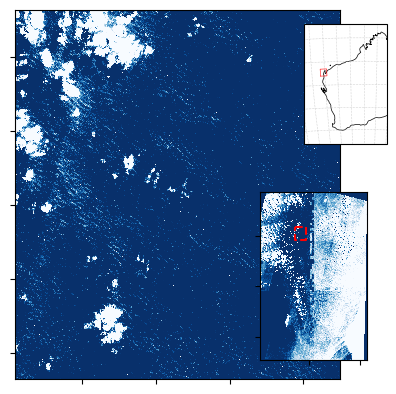

In [16]:
vmin =200
vmax = 275
import cartopy.crs as ccrs
cmap = "cmo.thermal_r"
# cmap = "bone_r"
cmap = "Blues_r"
fig = plt.figure()
z = ds['B02'].isel(t=0, x=slice(None,None, 5), y=slice(None,None,5)).copy()
#z = ds_area['sigma0'].copy()

zc = z.values#+1j
zc[np.isnan(zc)] = 0.
# zf,_,_,_ = filter2d(zc, 1, 1, 20, 0, 359.999, n=1)
# z[:] = np.abs(zf)

N=8
z[:] = convolve2d(zc, np.ones((N,N))/N**2, mode='same')


ax3=plt.subplot(111)

ax = fig.add_axes([0.55,0.15,0.35,0.35], )
# ds['B02'].isel(t=0, x=slice(7500,8500, 1), y=slice(8000,9000,1)).plot.imshow(vmin=100, vmax=300, cmap="Blues")
z.plot.imshow(vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False)

ax.set_aspect('equal')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
plt.plot(xbox, ybox, 'r--')
#plt.plot(113.93323333333333, -21.859933333333334,'md') # Nin 75 m

###
# Map inset
extent = [110,128,-38,-12]
mapproj = ccrs.Orthographic(123.0, -14)
ax2 = fig.add_axes([0.65,0.60,0.25,0.25], projection=mapproj)

ax2.gridlines(lw=0.4, ls=':')
ax2.coastlines(resolution='50m', lw=0.5)
#ax.fill(xybox[:,0],xybox[:,1],transform=mapproj)
#ax2.plot(0,0,'ro',transform=mapproj)

x1,y1,x2,y2 = [113, -23, 114.5, -21.5] # Ningaloo

xlims = [x1,x2]
ylims = [y1,y2]
xbox2 = [xlims[0], xlims[1],xlims[1], xlims[0], xlims[0]]
ybox2 = [ylims[0], ylims[0], ylims[1], ylims[1], ylims[0]]

ax2.plot(xbox2, ybox2,
         color='r', linewidth=0.4, marker='',
         transform=ccrs.Geodetic(), #remove this line to get straight lines
         )

ax2.set_extent(extent)

#ax3 = fig.add_axes([0.55,0.15,0.35,0.35], )
z2.plot.imshow(ax=ax3, vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False)
ax3.set_aspect('equal')

ax3.set_xticklabels([])
ax3.set_yticklabels([])
ax3.set_title('')
ax3.set_xlabel('')
ax3.set_ylabel('')

#plt.tight_layout()

outfile = f"../FIGURES/NingalooSentinel2_{t1}_{cmap}.png"
import os

cmap_name = cmap if isinstance(cmap, str) else getattr(cmap, "name", "cmap")
outdir = "../FIGURES"
os.makedirs(outdir, exist_ok=True)  # 关键：确保目录存在
outfile = os.path.join(outdir, f"NingalooSentinel2_{t1}_{cmap_name}.png")

plt.savefig(outfile, dpi=150, bbox_inches="tight")
print("saved:", outfile)

plt.savefig(outfile, dpi=150)
outfile

In [18]:
def export_s2_tiles_streaming(
    nc_file,
    var_name="B02",
    t_index=0,
    out_dir="../WEBDATA/S2_B02",
    tile=512,
    nan_fill=float("nan"),
    compress=False,          # True -> 写 gzip(.gz)
    engine=None,             # 可选: "h5netcdf" 或 "netcdf4"
):
    """
    逐块读取 NetCDF 并导出二进制瓦片（Float32, row-major），同时写 index.json。
    不会把整幅影像加载进内存。
    """
    import os, json, math, gzip
    import numpy as np
    import xarray as xr
    import pandas as pd

    os.makedirs(out_dir, exist_ok=True)
    tiles_dir = os.path.join(out_dir, "tiles")
    os.makedirs(tiles_dir, exist_ok=True)

    # 关键点：不要对整幅 .astype/.values；仅在 tile 上做
    ds = xr.open_dataset(nc_file, engine=engine)  # 如遇解码慢，可试 engine="h5netcdf"
    da = ds[var_name].isel(t=t_index)             # (y,x) 的 DataArray（懒加载/不进内存）

    ys, xs = int(da.sizes["y"]), int(da.sizes["x"])
    xcoord = da["x"].values   # 1D，小；加载没问题
    ycoord = da["y"].values

    n_row = math.ceil(ys / tile)
    n_col = math.ceil(xs / tile)

    # 索引与元数据
    index = {
        "version": 1,
        "var": var_name,
        "dtype": "float32",
        "order": "C",                     # row-major
        "shape": {"y": ys, "x": xs},
        "tile": tile,
        "n_row": n_row,
        "n_col": n_col,
        "timestamp": pd.Timestamp(ds["t"].values[t_index]).isoformat(),
        "coords": {
            "x_min": float(xcoord.min()), "x_max": float(xcoord.max()),
            "y_min": float(ycoord.min()), "y_max": float(ycoord.max()),
        },
        "tiles": []
    }

    # 运行统计（避免整幅 np.nanmin/np.nanmax）
    valid_total = 0
    vmin_glob = np.inf
    vmax_glob = -np.inf

    # 遍历瓦片
    for r in range(n_row):
        y0 = r * tile
        y1 = min((r + 1) * tile, ys)
        for c in range(n_col):
            x0 = c * tile
            x1 = min((c + 1) * tile, xs)

            # 只取这一块到内存，并在这个小块上转 float32
            tile_da = da.isel(y=slice(y0, y1), x=slice(x0, x1)).astype("float32")
            tile_np = tile_da.load().values   # 仅此 tile 进内存

            # NaN 处理（默认保留；若要替换为常数，改下行）
            if not np.isnan(nan_fill):
                tile_np = np.nan_to_num(tile_np, nan=nan_fill)

            # 写文件
            fname = f"r{r}_c{c}.bin"
            fpath = os.path.join(tiles_dir, fname)
            if compress:
                with gzip.open(fpath + ".gz", "wb") as f:
                    f.write(tile_np.tobytes(order="C"))
                fname += ".gz"
            else:
                with open(fpath, "wb") as f:
                    f.write(tile_np.tobytes(order="C"))

            # 更新统计
            finite_mask = np.isfinite(tile_np)
            cnt = int(finite_mask.sum())
            if cnt > 0:
                valid_total += cnt
                # 避免全 NaN 时 nanmin 报错
                tmin = float(np.nanmin(tile_np))
                tmax = float(np.nanmax(tile_np))
                if tmin < vmin_glob: vmin_glob = tmin
                if tmax > vmax_glob: vmax_glob = tmax

            # 索引记录（给前端定位）
            index["tiles"].append({
                "r": r, "c": c,
                "y0": int(y0), "y1": int(y1),
                "x0": int(x0), "x1": int(x1),
                "h": int(y1 - y0), "w": int(x1 - x0),
                "file": fname,
                "x_range": [float(xcoord[x0]), float(xcoord[x1-1])],
                "y_range": [float(ycoord[y0]), float(ycoord[y1-1])],
            })

    # 写全局统计
    if valid_total == 0:
        stats = {"valid_count": 0, "vmin": float("nan"), "vmax": float("nan")}
    else:
        stats = {"valid_count": int(valid_total), "vmin": float(vmin_glob), "vmax": float(vmax_glob)}
    index["stats"] = stats

    # index.json
    with open(os.path.join(out_dir, "index.json"), "w", encoding="utf-8") as f:
        json.dump(index, f, ensure_ascii=False, indent=2)

    ds.close()
    print(f"[OK] 输出目录：{out_dir}")
    print(f" - 瓦片目录：{tiles_dir}")
    print(f" - 索引文件：{os.path.join(out_dir, 'index.json')}")
    print(f" - 有效像元: {stats['valid_count']}, vmin={stats['vmin']}, vmax={stats['vmax']}")
    return out_dir


# Use it like this:
nc_file = "../DATA/Sentinel2_L2A_B02_2025-08-01.nc"  # 确认这个文件确实存在
out_dir = "../WEBDATA/S2_B02"

export_s2_tiles_streaming(
    nc_file,
    var_name="B02",
    tile=512,
    compress=False,
    engine="h5netcdf",   # 没装就去 pip/conda 安装；装不了可去掉该参数
    out_dir=out_dir,
)


[OK] 输出目录：../WEBDATA/S2_B02
 - 瓦片目录：../WEBDATA/S2_B02\tiles
 - 索引文件：../WEBDATA/S2_B02\index.json
 - 有效像元: 686908168, vmin=-999.0, vmax=8728.0


'../WEBDATA/S2_B02'